In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)


In [3]:
# =========================
# 1) Dane (syntetyczne)
# =========================
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=12,
    n_redundant=6,
    n_classes=2,
    class_sep=1.2,
    flip_y=0.03,        # trochę szumu w etykietach
    random_state=42
)


In [5]:
# =========================
# 2) Podział train/test
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)


In [6]:
# =========================
# 3) Pipeline: skalowanie + SVM
# =========================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True))  # probability=True -> predict_proba dla ROC/PR
])

In [8]:
# =========================
# 4) Siatka parametrów (tuning)
# =========================
param_grid = [
    # jądro liniowe
    {"svm__kernel": ["linear"],
     "svm__C": [0.1, 1, 10, 100]},
    # RBF
    {"svm__kernel": ["rbf"],
     "svm__C": [0.1, 1, 10, 100],
     "svm__gamma": ["scale", 0.1, 0.01, 0.001]}
]


In [9]:
# =========================
# 5) GridSearchCV (CV=5)
# =========================
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Najlepsze parametry:", grid.best_params_)
print("Najlepsza accuracy (CV):", grid.best_score_)


Najlepsze parametry: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Najlepsza accuracy (CV): 0.9554666666666666


In [10]:
# =========================
# 6) Ewaluacja na teście
# =========================
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nAccuracy (TEST):", accuracy_score(y_test, y_pred))
print("\nROC-AUC (TEST):", roc_auc_score(y_test, y_proba))
print("PR-AUC  (TEST):", average_precision_score(y_test, y_proba))

print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))



Accuracy (TEST): 0.964

ROC-AUC (TEST): 0.984782041042025
PR-AUC  (TEST): 0.9864970944562251

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       624
           1       0.97      0.95      0.96       626

    accuracy                           0.96      1250
   macro avg       0.96      0.96      0.96      1250
weighted avg       0.96      0.96      0.96      1250



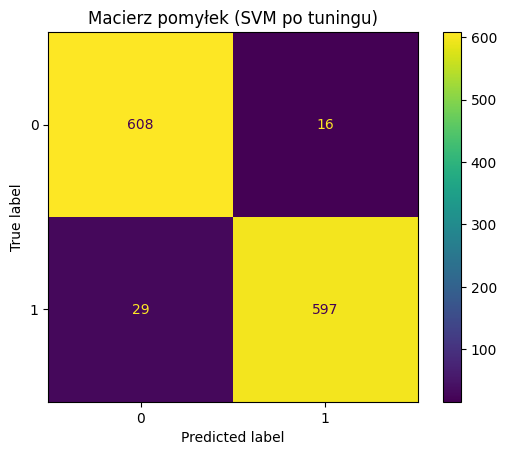

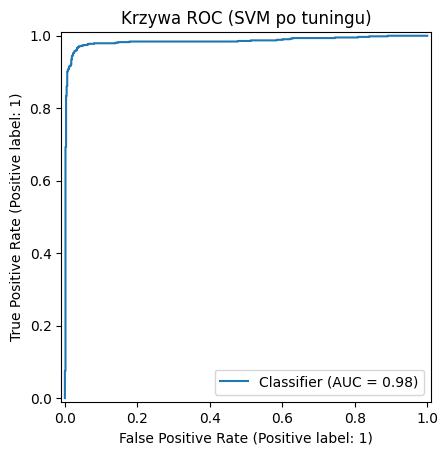

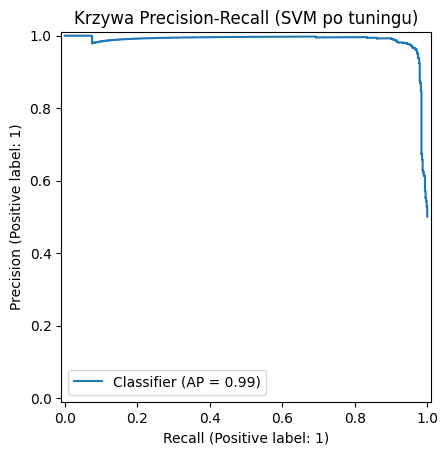

In [11]:
# =========================
# 7) Wykresy: Confusion, ROC, PR
# =========================
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Macierz pomyłek (SVM po tuningu)")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Krzywa ROC (SVM po tuningu)")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Krzywa Precision-Recall (SVM po tuningu)")
plt.show()